**DermaScan AI: Comparing CNN, ResNet-18, ViT-Scratch & ViT-B16 for Skin Lesion Classification**

---


A study on the effect of pretraining vs architecture for small medical datasets | HAM10000 · DermaMNIST · PyTorch

In [ ]:
import torch
import sys

# Check GPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f" GPU available: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    device = torch.device('cpu')
    print(" No GPU detected. Some cells may run slowly.")
    print("   Go to Runtime → Change runtime type → GPU")

print(f"\n Python {sys.version.split()[0]}")
print(f" PyTorch {torch.__version__}")

# Set random seeds for reproducibility
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f" Random seed set to {SEED}")

%matplotlib inline


 GPU available: Tesla T4
   Memory: 15.6 GB

 Python 3.12.13
 PyTorch 2.11.0+cu128
 Random seed set to 42


# DermaScan AI: Vision Encoders for Automated Dermatology Screening

**Implementation Notebook — 4-Model Comparison Edition**

This notebook trains and compares **four models** to answer:
> *How much does pretraining matter vs architecture choice for medical imaging?*

| Model | Pretraining | Architecture |
|---|---|---|
| CNN from scratch | ❌ None | Simple ConvNet |
| ResNet-18 pretrained | ✅ ImageNet | CNN with skip connections |
| ViT from scratch | ❌ None | Transformer |
| ViT-B/16 pretrained | ✅ ImageNet-21k | Full Vision Transformer |

Pipeline:
1. Data loading with class-weighted sampling (32×32 for scratch models; 224×224 for pretrained ViT)
2. Four model architectures defined
3. Fixed loss function (weighted CE + focal loss, label smoothing)
4. Training loop with best-checkpoint saving (by melanoma sensitivity)
5. Full evaluation: accuracy, balanced accuracy, macro-F1, AUROC
6. 4-way comparison table + training curves
7. Grad-CAM and ViT attention rollout on false-negative melanomas
8. Deployment: HuggingFace Hub + Gradio melanoma screening app

**Dataset:** DermaMNIST — 10,015 real dermatoscopic images across 7 skin lesion types (HAM10000).  
**Runtime:** Google Colab (T4 GPU required)


In [ ]:
# Setup and dependencies
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, roc_auc_score,
                             balanced_accuracy_score, f1_score)
from sklearn.calibration import CalibrationDisplay
from torch.utils.data import Dataset
import time, os, json

!pip install -q medmnist timm
import medmnist
from medmnist import DermaMNIST
import timm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# DermaMNIST class definitions
NUM_CLASSES = 7
CLASS_NAMES = ['actinic_keratosis', 'basal_cell_carcinoma', 'benign_keratosis',
               'dermatofibroma', 'melanoma', 'melanocytic_nevus', 'vascular_lesion']
MELANOMA_IDX = 4  # Melanoma is class 4


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.4 MB/s eta 0:00:00
Using device: cuda


## Section 1: Data Loading and Preprocessing


In [ ]:
class IntLabelDataset(Dataset):
    """Wraps MedMNIST to return integer labels and expose .targets."""
    def __init__(self, dataset):
        self.dataset = dataset
        self.targets = [int(dataset[i][1].item()) for i in range(len(dataset))]
    def __len__(self):
        return len(self.dataset)
    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        return img, int(label.item())


def make_loaders(img_size=32, batch_size=64):
    """
    Load DermaMNIST at the requested img_size.
    Use img_size=32 for scratch models, img_size=224 for pretrained ViT-B/16.
    """
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    transform_train = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(30),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
        transforms.RandomErasing(p=0.1),
    ])
    transform_eval = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
    ])

    train_raw = DermaMNIST(split='train', download=True, transform=transform_train)
    val_raw   = DermaMNIST(split='val',   download=True, transform=transform_eval)
    test_raw  = DermaMNIST(split='test',  download=True, transform=transform_eval)

    trainset = IntLabelDataset(train_raw)
    valset   = IntLabelDataset(val_raw)
    testset  = IntLabelDataset(test_raw)

    class_counts  = np.bincount(trainset.targets, minlength=NUM_CLASSES)
    class_weights = len(trainset.targets) / (NUM_CLASSES * class_counts + 1e-6)
    class_weights = torch.FloatTensor(class_weights)

    sample_weights = class_weights[trainset.targets]
    sampler = torch.utils.data.WeightedRandomSampler(
        weights=sample_weights, num_samples=len(trainset), replacement=True)

    train_loader = torch.utils.data.DataLoader(
        trainset, batch_size=batch_size, sampler=sampler, num_workers=2, pin_memory=True)
    val_loader = torch.utils.data.DataLoader(
        valset, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = torch.utils.data.DataLoader(
        testset, batch_size=batch_size, shuffle=False, num_workers=2)

    return train_loader, val_loader, test_loader, class_weights, class_counts


# 32×32 loaders (used by CNN-scratch, ResNet-18, ViT-scratch)
train_loader, val_loader, test_loader, class_weights, train_class_counts = \
    make_loaders(img_size=32)

# 224×224 loaders (used by pretrained ViT-B/16 — larger, slower)
train_loader_224, val_loader_224, test_loader_224, _, _ = \
    make_loaders(img_size=224, batch_size=32)

print(f'32×32  — Train: {len(train_loader.dataset):,}  Val: {len(val_loader.dataset):,}  Test: {len(test_loader.dataset):,}')
print(f'224×224 — Train: {len(train_loader_224.dataset):,}  Val: {len(val_loader_224.dataset):,}  Test: {len(test_loader_224.dataset):,}')
print(f'Class weights: {class_weights.numpy().round(2)}')


100%|██████████| 19.7M/19.7M [00:01<00:00, 10.0MB/s]


32×32  — Train: 7,007  Val: 1,003  Test: 2,005
224×224 — Train: 7,007  Val: 1,003  Test: 2,005
Class weights: [ 4.39  2.79  1.3  12.51  1.28  0.21 10.11]


## Section 2: Exploratory Data Analysis


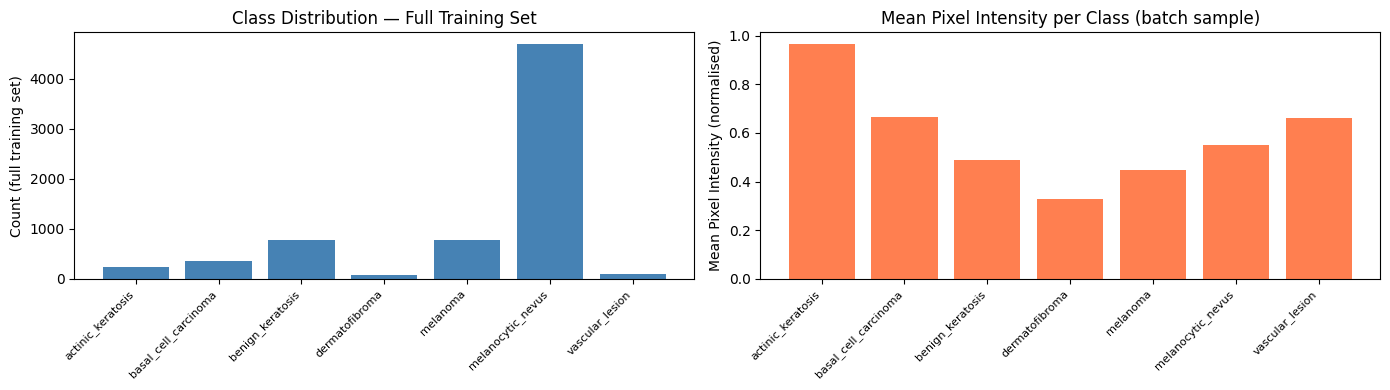

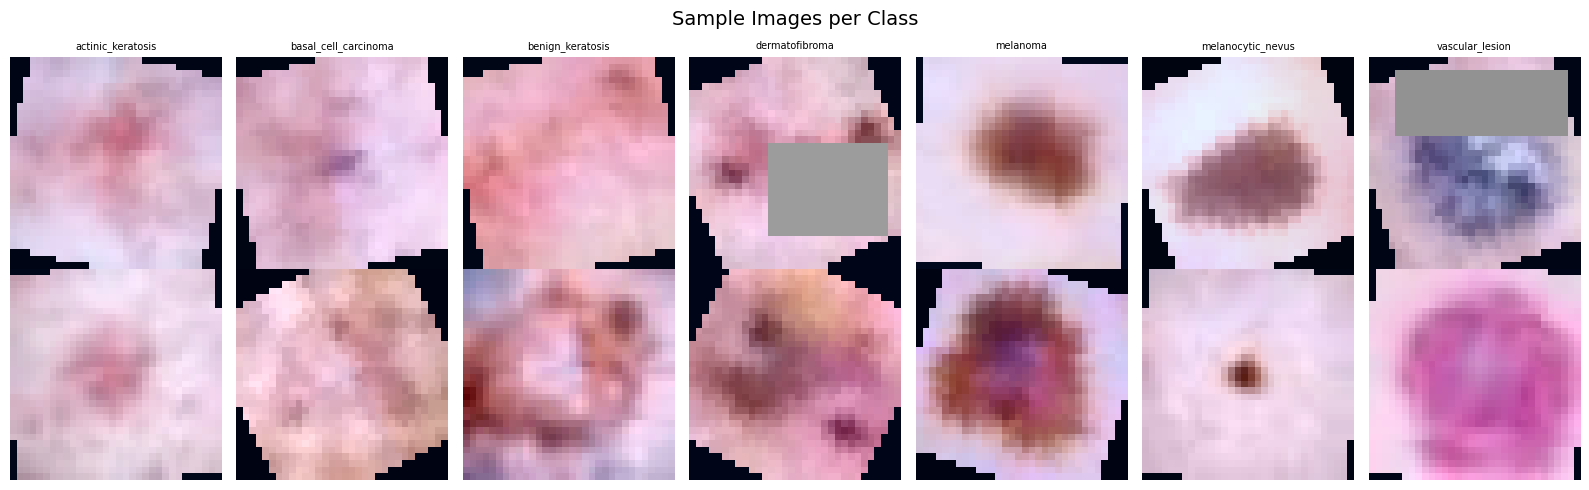


Full training-set class counts:
  actinic_keratosis        :   228 (3.3%)
  basal_cell_carcinoma     :   359 (5.1%)
  benign_keratosis         :   769 (11.0%)
  dermatofibroma           :    80 (1.1%)
  melanoma                 :   779 (11.1%)
  melanocytic_nevus        :  4693 (67.0%)
  vascular_lesion          :    99 (1.4%)


In [ ]:
def run_eda(train_loader, class_names, train_class_counts):
    """
    EDA using full-dataset statistics.
    FIX: class distribution uses trainset.targets (all samples), not one batch.
    """
    # --- Full-dataset class distribution ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].bar(range(len(class_names)), train_class_counts, color='steelblue')
    axes[0].set_xticks(range(len(class_names)))
    axes[0].set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
    axes[0].set_ylabel('Count (full training set)')
    axes[0].set_title('Class Distribution — Full Training Set')

    # --- Mean pixel intensity per class (from one batch for speed) ---
    images, labels = next(iter(train_loader))
    mean_intensities = []
    for cls in range(len(class_names)):
        mask = labels == cls
        if mask.sum() > 0:
            mean_intensities.append(images[mask].mean().item())
        else:
            mean_intensities.append(0.0)

    axes[1].bar(range(len(class_names)), mean_intensities, color='coral')
    axes[1].set_xticks(range(len(class_names)))
    axes[1].set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
    axes[1].set_ylabel('Mean Pixel Intensity (normalised)')
    axes[1].set_title('Mean Pixel Intensity per Class (batch sample)')
    plt.tight_layout()
    plt.show()

    # --- Sample images per class ---
    fig2, axes2 = plt.subplots(2, 7, figsize=(16, 5))
    fig2.suptitle('Sample Images per Class', fontsize=14)
    for cls in range(min(7, len(class_names))):
        mask = labels == cls
        if mask.sum() > 0:
            idx0 = mask.nonzero(as_tuple=True)[0][0]
            img  = images[idx0].permute(1,2,0).numpy()
            img  = (img - img.min()) / (img.max() - img.min())
            axes2[0, cls].imshow(img)
            axes2[0, cls].set_title(class_names[cls], fontsize=7)
            axes2[0, cls].axis('off')
            if mask.sum() > 1:
                idx1 = mask.nonzero(as_tuple=True)[0][1]
                img2 = images[idx1].permute(1,2,0).numpy()
                img2 = (img2 - img2.min()) / (img2.max() - img2.min())
                axes2[1, cls].imshow(img2)
        axes2[1, cls].axis('off')
    plt.tight_layout()
    plt.show()

    print('\nFull training-set class counts:')
    for name, cnt in zip(class_names, train_class_counts):
        print(f'  {name:<25}: {cnt:>5} ({cnt/sum(train_class_counts)*100:.1f}%)')


run_eda(train_loader, CLASS_NAMES, train_class_counts)


## Section 3: Model Architectures



In [ ]:
# ── Model 1: CNN from scratch (baseline) ────────────────────────────────────
class CNNScratch(nn.Module):
    """Small 4-block CNN trained from random init on 32×32 images."""
    def __init__(self, num_classes=7):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.GELU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.GELU(),
            nn.MaxPool2d(2),                # 16×16
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.GELU(),
            nn.MaxPool2d(2),                # 8×8
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.GELU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.GELU(),
            nn.MaxPool2d(2),                # 4×4
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.GELU(),
            nn.AdaptiveAvgPool2d(1),        # 1×1
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 128), nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))


# ── Model 2: ResNet-18 pretrained (ImageNet) ─────────────────────────────────
def create_resnet18_pretrained(num_classes=7):
    """ResNet-18 fine-tuned for 32×32 medical images (CIFAR-style head)."""
    model = torchvision.models.resnet18(weights='IMAGENET1K_V1')
    model.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc      = nn.Linear(512, num_classes)
    return model


# ── Model 3: ViT from scratch ────────────────────────────────────────────────
class SimpleViTForMedical(nn.Module):
    """Vision Transformer trained from random init on 32×32 images."""
    def __init__(self, img_size=32, patch_size=4, embed_dim=192,
                 num_heads=6, num_layers=6, num_classes=7):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.patch_embed  = nn.Conv2d(3, embed_dim, patch_size, stride=patch_size)
        self.cls_token    = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed    = nn.Parameter(torch.randn(1, self.num_patches + 1, embed_dim) * 0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=embed_dim * 4,
            activation='gelu', batch_first=True, norm_first=True, dropout=0.1)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim), nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x).flatten(2).transpose(1, 2)
        x = torch.cat([self.cls_token.expand(B, -1, -1), x], dim=1) + self.pos_embed
        x = self.norm(self.transformer(x))
        return self.head(x[:, 0])


# ── Model 4: ViT-B/16 pretrained (timm, ImageNet-21k) ───────────────────────
def create_vit_b16_pretrained(num_classes=7):
    """
    Pretrained ViT-B/16 from timm, fine-tuned on DermaMNIST at 224×224.
    Uses vit_base_patch16_224 pretrained on ImageNet-21k then fine-tuned on ImageNet-1k.
    Only the classification head is replaced; all other weights start from pretraining.
    """
    model = timm.create_model(
        'vit_base_patch16_224',
        pretrained=True,
        num_classes=num_classes,
    )
    return model


# Instantiate and print param counts
cnn_scratch  = CNNScratch().to(device)
resnet18_pt  = create_resnet18_pretrained().to(device)
vit_scratch  = SimpleViTForMedical(img_size=32).to(device)
vit_b16_pt   = create_vit_b16_pretrained().to(device)

for name, m in [('CNN scratch',       cnn_scratch),
                ('ResNet-18 pretrained', resnet18_pt),
                ('ViT scratch',        vit_scratch),
                ('ViT-B/16 pretrained', vit_b16_pt)]:
    n = sum(p.numel() for p in m.parameters())
    print(f'  {name:<25}: {n:>12,} params')


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 130MB/s]
/tmp/ipykernel_2616/307787323.py:53: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

  CNN scratch              :      617,383 params
  ResNet-18 pretrained     :   11,172,423 params
  ViT scratch              :    2,730,055 params
  ViT-B/16 pretrained      :   85,804,039 params


## Section 4: Loss Function



In [ ]:
class DermaScanLoss(nn.Module):
    """
    Loss = Weighted_CE(label_smoothing=0.1)  +  lambda * FocalLoss(melanoma)

    FIX: removed L2 regularisation on logits — AdamW weight_decay covers this.
    FIX: added label_smoothing=0.1 to discourage overconfident predictions.
    """
    def __init__(self, class_weights, melanoma_idx=MELANOMA_IDX,
                 focal_gamma=2.0, focal_weight=0.3):
        super().__init__()
        self.ce_loss      = nn.CrossEntropyLoss(weight=class_weights,
                                                label_smoothing=0.1)
        self.melanoma_idx = melanoma_idx
        self.focal_gamma  = focal_gamma
        self.focal_weight = focal_weight

    def forward(self, logits, targets):
        ce = self.ce_loss(logits, targets)

        probs    = F.softmax(logits, dim=-1)
        mel_prob = probs[:, self.melanoma_idx]
        mel_mask = (targets == self.melanoma_idx).float()

        p_t      = mel_prob * mel_mask + (1 - mel_prob) * (1 - mel_mask)
        focal    = -((1 - p_t) ** self.focal_gamma) * torch.log(p_t + 1e-8)
        focal_loss = focal.mean()

        return ce + self.focal_weight * focal_loss


loss_fn = DermaScanLoss(class_weights.to(device))
print('Loss: weighted CE (label_smoothing=0.1) + melanoma focal loss')


Loss: weighted CE (label_smoothing=0.1) + melanoma focal loss


## Section 5: Training Pipeline


In [ ]:
def train_and_evaluate(model, train_loader, val_loader, loss_fn,
                       num_epochs=15, lr=1e-3, model_name='model'):
    """Train model and track melanoma-specific metrics per epoch.

    FIX: zero_grad() → forward → loss → backward → step  (correct order).
    FIX: ValueError-only except clause for roc_auc_score.
    """
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = {'train_loss': [], 'val_acc': [], 'val_balanced_acc': [],
               'mel_sensitivity': [], 'mel_auroc': []}
    best_mel_sens = 0
    best_state    = None

    for epoch in range(num_epochs):
        # ── Training ────────────────────────────────────────────────────────
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()        # FIX: zero_grad BEFORE forward
            outputs = model(images)
            loss    = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        scheduler.step()

        # ── Validation ──────────────────────────────────────────────────────
        model.eval()
        all_preds, all_labels, all_probs = [], [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                probs   = F.softmax(outputs, dim=-1)
                preds   = outputs.argmax(1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        all_preds  = np.array(all_preds)
        all_labels = np.array(all_labels)
        all_probs  = np.array(all_probs)

        val_acc      = (all_preds == all_labels).mean() * 100
        balanced_acc = balanced_accuracy_score(all_labels, all_preds) * 100

        mel_true  = (all_labels == MELANOMA_IDX).astype(int)
        mel_pred  = (all_preds  == MELANOMA_IDX).astype(int)
        mel_tp    = ((mel_pred == 1) & (mel_true == 1)).sum()
        mel_fn    = ((mel_pred == 0) & (mel_true == 1)).sum()
        mel_sensitivity = mel_tp / (mel_tp + mel_fn + 1e-8) * 100

        try:                                          # FIX: specific exception
            mel_auroc = roc_auc_score(mel_true, all_probs[:, MELANOMA_IDX])
        except ValueError:
            mel_auroc = 0.5

        history['train_loss'].append(running_loss / len(train_loader))
        history['val_acc'].append(val_acc)
        history['val_balanced_acc'].append(balanced_acc)
        history['mel_sensitivity'].append(mel_sensitivity)
        history['mel_auroc'].append(mel_auroc)

        if mel_sensitivity > best_mel_sens:
            best_mel_sens = mel_sensitivity
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'  [{model_name}] Epoch {epoch+1:02d}/{num_epochs}: '
                  f'Loss={running_loss/len(train_loader):.3f}  '
                  f'Acc={val_acc:.1f}%  BalAcc={balanced_acc:.1f}%  '
                  f'MelSens={mel_sensitivity:.1f}%  AUROC={mel_auroc:.3f}')

    return history, best_state


In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# Train all four models.
#
# Epoch schedule:
#   CNN scratch      → 30 epochs  (needs more time without pretraining)
#   ResNet-18 pt     → 30 epochs  (fine-tuning converges fast but benefits from longer run)
#   ViT scratch      → 50 epochs  (transformers need more epochs from scratch)
#   ViT-B/16 pt      → 20 epochs  (pretrained — converges quickly, avoid overfitting)
#
# Best checkpoint saved by melanoma sensitivity (most clinically relevant).
# ────────────────────────────────────────────────────────────────────────────

print('=' * 60)
print('Model 1/4: CNN from Scratch')
print('=' * 60)
cnn_scratch   = CNNScratch().to(device)
loss_fn       = DermaScanLoss(class_weights.to(device))
cnn_history, cnn_best = train_and_evaluate(
    cnn_scratch, train_loader, val_loader, loss_fn,
    num_epochs=30, lr=1e-3, model_name='CNN-scratch')

print('\n' + '=' * 60)
print('Model 2/4: ResNet-18 Pretrained')
print('=' * 60)
resnet18_pt   = create_resnet18_pretrained().to(device)
loss_fn       = DermaScanLoss(class_weights.to(device))
resnet_history, resnet_best = train_and_evaluate(
    resnet18_pt, train_loader, val_loader, loss_fn,
    num_epochs=30, lr=1e-3, model_name='ResNet-18-pt')

print('\n' + '=' * 60)
print('Model 3/4: ViT from Scratch')
print('=' * 60)
vit_scratch   = SimpleViTForMedical(img_size=32).to(device)
loss_fn       = DermaScanLoss(class_weights.to(device))
vit_history, vit_best = train_and_evaluate(
    vit_scratch, train_loader, val_loader, loss_fn,
    num_epochs=50, lr=3e-4, model_name='ViT-scratch')

print('\n' + '=' * 60)
print('Model 4/4: ViT-B/16 Pretrained (224×224 — ~2× slower per epoch)')
print('=' * 60)
vit_b16_pt    = create_vit_b16_pretrained().to(device)
loss_fn_224   = DermaScanLoss(class_weights.to(device))
# Use a lower LR for fine-tuning — pretrained weights are fragile
vit_b16_history, vit_b16_best = train_and_evaluate(
    vit_b16_pt, train_loader_224, val_loader_224, loss_fn_224,
    num_epochs=20, lr=2e-5, model_name='ViT-B16-pt')

print('\n All four models trained. Best checkpoints saved by melanoma sensitivity.')


Model 1/4: CNN from Scratch
  [CNN-scratch] Epoch 01/30: Loss=1.294  Acc=6.9%  BalAcc=27.7%  MelSens=44.1%  AUROC=0.700
  [CNN-scratch] Epoch 05/30: Loss=1.013  Acc=9.9%  BalAcc=40.0%  MelSens=55.9%  AUROC=0.737
  [CNN-scratch] Epoch 10/30: Loss=0.810  Acc=20.0%  BalAcc=50.1%  MelSens=55.9%  AUROC=0.813
  [CNN-scratch] Epoch 15/30: Loss=0.715  Acc=22.5%  BalAcc=54.3%  MelSens=71.2%  AUROC=0.804
  [CNN-scratch] Epoch 20/30: Loss=0.654  Acc=27.1%  BalAcc=56.0%  MelSens=72.1%  AUROC=0.790
  [CNN-scratch] Epoch 25/30: Loss=0.599  Acc=32.7%  BalAcc=57.1%  MelSens=73.9%  AUROC=0.819
  [CNN-scratch] Epoch 30/30: Loss=0.597  Acc=36.4%  BalAcc=56.3%  MelSens=77.5%  AUROC=0.827

Model 2/4: ResNet-18 Pretrained
  [ResNet-18-pt] Epoch 01/30: Loss=1.251  Acc=9.0%  BalAcc=35.2%  MelSens=54.1%  AUROC=0.812
  [ResNet-18-pt] Epoch 05/30: Loss=0.812  Acc=18.8%  BalAcc=46.6%  MelSens=47.7%  AUROC=0.782
  [ResNet-18-pt] Epoch 10/30: Loss=0.638  Acc=22.5%  BalAcc=48.9%  MelSens=67.6%  AUROC=0.805
  [ResNet

/tmp/ipykernel_2616/307787323.py:53: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)


  [ViT-scratch] Epoch 01/50: Loss=1.430  Acc=6.1%  BalAcc=32.0%  MelSens=32.4%  AUROC=0.698
  [ViT-scratch] Epoch 05/50: Loss=1.087  Acc=6.5%  BalAcc=33.5%  MelSens=27.9%  AUROC=0.734
  [ViT-scratch] Epoch 10/50: Loss=0.980  Acc=10.9%  BalAcc=40.8%  MelSens=56.8%  AUROC=0.746
  [ViT-scratch] Epoch 15/50: Loss=0.881  Acc=25.1%  BalAcc=51.1%  MelSens=63.1%  AUROC=0.749
  [ViT-scratch] Epoch 20/50: Loss=0.825  Acc=30.2%  BalAcc=50.9%  MelSens=56.8%  AUROC=0.773
  [ViT-scratch] Epoch 25/50: Loss=0.742  Acc=24.6%  BalAcc=52.4%  MelSens=65.8%  AUROC=0.796
  [ViT-scratch] Epoch 30/50: Loss=0.670  Acc=23.5%  BalAcc=50.1%  MelSens=64.0%  AUROC=0.778
  [ViT-scratch] Epoch 35/50: Loss=0.635  Acc=30.7%  BalAcc=54.3%  MelSens=69.4%  AUROC=0.797
  [ViT-scratch] Epoch 40/50: Loss=0.599  Acc=36.8%  BalAcc=52.9%  MelSens=72.1%  AUROC=0.811
  [ViT-scratch] Epoch 45/50: Loss=0.583  Acc=36.7%  BalAcc=53.7%  MelSens=70.3%  AUROC=0.804
  [ViT-scratch] Epoch 50/50: Loss=0.576  Acc=37.9%  BalAcc=54.1%  MelSen

  [ViT-B16-pt] Epoch 01/20: Loss=0.892  Acc=16.7%  BalAcc=48.6%  MelSens=68.5%  AUROC=0.793
  [ViT-B16-pt] Epoch 05/20: Loss=0.462  Acc=45.3%  BalAcc=66.0%  MelSens=82.9%  AUROC=0.867
  [ViT-B16-pt] Epoch 10/20: Loss=0.403  Acc=45.0%  BalAcc=62.3%  MelSens=74.8%  AUROC=0.876
  [ViT-B16-pt] Epoch 15/20: Loss=0.381  Acc=51.0%  BalAcc=63.4%  MelSens=77.5%  AUROC=0.886
  [ViT-B16-pt] Epoch 20/20: Loss=0.372  Acc=53.8%  BalAcc=64.8%  MelSens=76.6%  AUROC=0.891

✅ All four models trained. Best checkpoints saved by melanoma sensitivity.


## Section 6: Training Curves


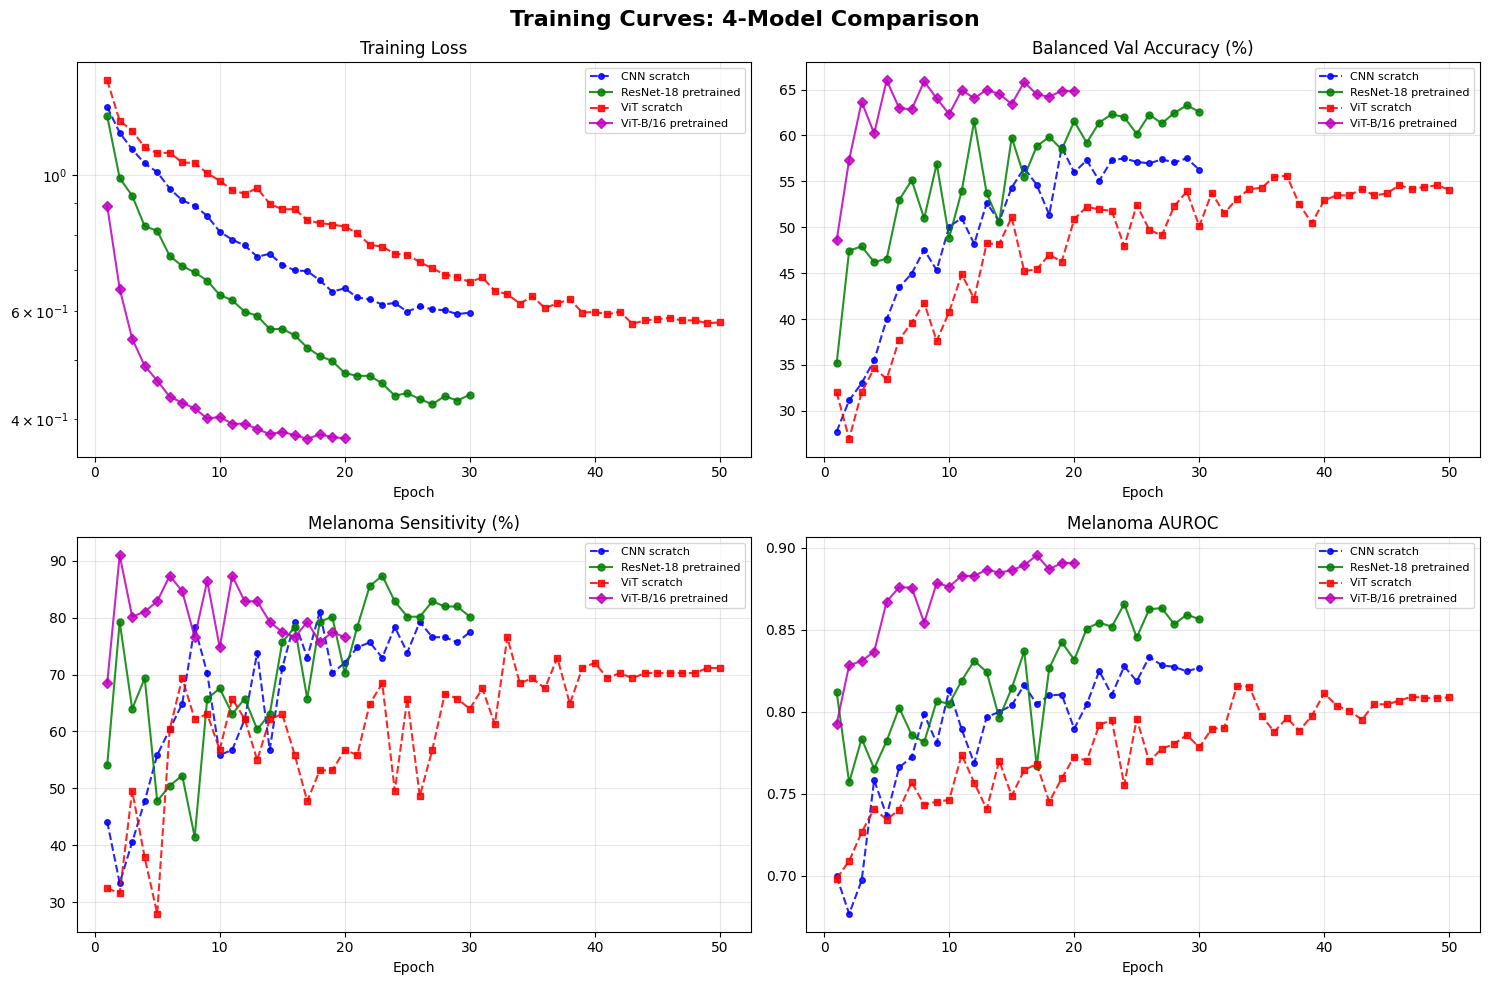

In [ ]:
def plot_training_curves_4(cnn_h, resnet_h, vit_h, vit_b16_h):
    """Plot training loss, balanced accuracy, melanoma sensitivity, and AUROC for all 4 models."""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Training Curves: 4-Model Comparison', fontsize=16, fontweight='bold')

    configs = [
        ('train_loss',       'Training Loss',             True,  True),
        ('val_balanced_acc', 'Balanced Val Accuracy (%)', False, False),
        ('mel_sensitivity',  'Melanoma Sensitivity (%)',  False, False),
        ('mel_auroc',        'Melanoma AUROC',            False, False),
    ]
    styles = [
        ('CNN scratch',        cnn_h,      'b--o',  4),
        ('ResNet-18 pretrained', resnet_h, 'g-o',   5),
        ('ViT scratch',        vit_h,      'r--s',  4),
        ('ViT-B/16 pretrained', vit_b16_h, 'm-D',   5),
    ]

    for ax, (key, title, log_scale, _) in zip(axes.flat, configs):
        for label, hist, fmt, ms in styles:
            epochs = range(1, len(hist[key]) + 1)
            ax.plot(epochs, hist[key], fmt, ms=ms, label=label, alpha=0.85)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        if log_scale:
            ax.set_yscale('log')

    plt.tight_layout()
    plt.savefig('training_curves_4models.png', dpi=150, bbox_inches='tight')
    plt.show()
    #print("Saved training_curves_4models.png')


plot_training_curves_4(cnn_history, resnet_history, vit_history, vit_b16_history)


## Section 7: Comprehensive Evaluation





 ResNet-18 — Test Set Results
  Overall Accuracy:    42.7%
  Balanced Accuracy:   63.2%   ← imbalance-corrected
  Macro F1:            38.5%
  Melanoma Sensitivity:81.6%  (target >90%)
  Melanoma Specificity:70.7%  (target >85%)
  Melanoma AUROC:      0.845


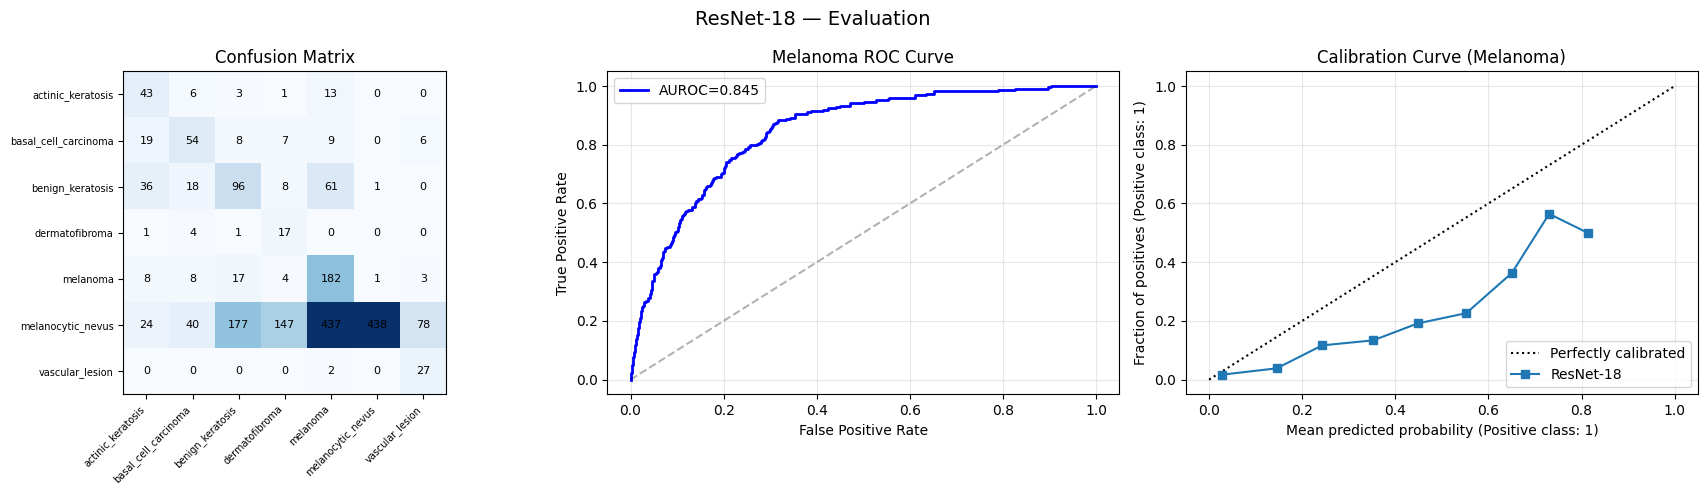

/tmp/ipykernel_2616/307787323.py:53: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)



 ViT — Test Set Results
  Overall Accuracy:    34.4%
  Balanced Accuracy:   54.1%   ← imbalance-corrected
  Macro F1:            32.3%
  Melanoma Sensitivity:77.1%  (target >90%)
  Melanoma Specificity:70.0%  (target >85%)
  Melanoma AUROC:      0.815


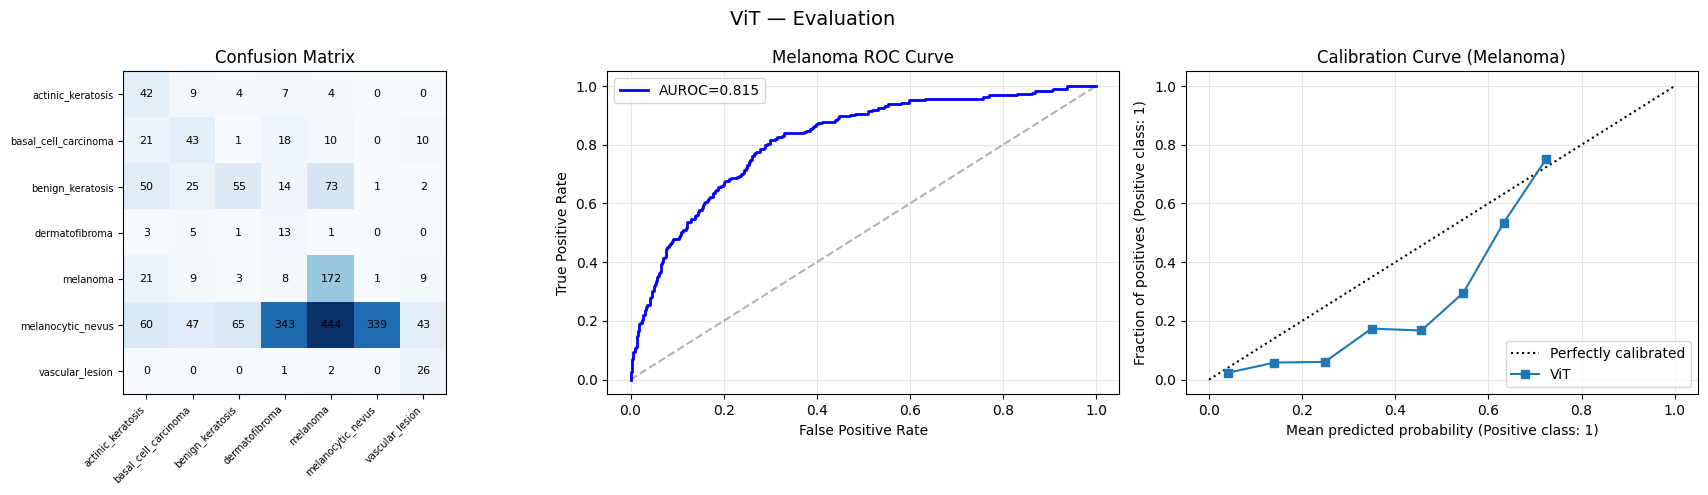

In [ ]:
def full_evaluation(model, test_loader, model_name='Model'):
    """Comprehensive evaluation with confusion matrix, ROC, and calibration curve.

    NEW: balanced accuracy, macro-F1, calibration display.
    """
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            probs  = F.softmax(model(images), dim=-1)
            preds  = probs.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    accuracy     = (all_preds == all_labels).mean() * 100
    balanced_acc = balanced_accuracy_score(all_labels, all_preds) * 100
    macro_f1     = f1_score(all_labels, all_preds, average='macro') * 100

    mel_true = (all_labels == MELANOMA_IDX).astype(int)
    mel_pred = (all_preds  == MELANOMA_IDX).astype(int)
    mel_tp   = ((mel_pred == 1) & (mel_true == 1)).sum()
    mel_fp   = ((mel_pred == 1) & (mel_true == 0)).sum()
    mel_fn   = ((mel_pred == 0) & (mel_true == 1)).sum()
    mel_tn   = ((mel_pred == 0) & (mel_true == 0)).sum()

    mel_sens  = mel_tp / (mel_tp + mel_fn + 1e-8) * 100
    mel_spec  = mel_tn / (mel_tn + mel_fp + 1e-8) * 100
    mel_auroc = roc_auc_score(mel_true, all_probs[:, MELANOMA_IDX])

    print(f'\n{"="*55}')
    print(f' {model_name} — Test Set Results')
    print(f'{"="*55}')
    print(f'  Overall Accuracy:    {accuracy:.1f}%')
    print(f'  Balanced Accuracy:   {balanced_acc:.1f}%   ← imbalance-corrected')
    print(f'  Macro F1:            {macro_f1:.1f}%')
    print(f'  Melanoma Sensitivity:{mel_sens:.1f}%  (target >90%)')
    print(f'  Melanoma Specificity:{mel_spec:.1f}%  (target >85%)')
    print(f'  Melanoma AUROC:      {mel_auroc:.3f}')

    # ── Confusion matrix + ROC + Calibration ────────────────────────────────
    cm  = confusion_matrix(all_labels, all_preds)
    fpr, tpr, _ = roc_curve(mel_true, all_probs[:, MELANOMA_IDX])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{model_name} — Evaluation', fontsize=14)

    # Confusion matrix
    axes[0].imshow(cm, cmap='Blues')
    axes[0].set_xticks(range(NUM_CLASSES))
    axes[0].set_yticks(range(NUM_CLASSES))
    axes[0].set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=7)
    axes[0].set_yticklabels(CLASS_NAMES, fontsize=7)
    axes[0].set_title('Confusion Matrix')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            axes[0].text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=8)

    # ROC curve
    axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUROC={mel_auroc:.3f}')
    axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('Melanoma ROC Curve')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Calibration curve (NEW)
    CalibrationDisplay.from_predictions(
        mel_true, all_probs[:, MELANOMA_IDX],
        n_bins=10, name=model_name, ax=axes[2])
    axes[2].set_title('Calibration Curve (Melanoma)')
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'eval_{model_name.lower().replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    return {'accuracy': accuracy, 'balanced_acc': balanced_acc,
            'macro_f1': macro_f1,
            'mel_sensitivity': mel_sens, 'mel_specificity': mel_spec,
            'mel_auroc': mel_auroc}


resnet18_pt_eval = create_resnet18_pretrained().to(device)
resnet18_pt_eval.load_state_dict(resnet_best)
resnet_metrics = full_evaluation(resnet18_pt_eval,   test_loader, 'ResNet-18')

vit_scratch_eval = SimpleViTForMedical(img_size=32).to(device)
vit_scratch_eval.load_state_dict(vit_best)
vit_metrics    = full_evaluation(vit_scratch_eval, test_loader, 'ViT')

Evaluating CNN scratch...

 CNN-scratch — Test Set Results
  Overall Accuracy:    32.0%
  Balanced Accuracy:   55.0%   ← imbalance-corrected
  Macro F1:            29.1%
  Melanoma Sensitivity:76.2%  (target >90%)
  Melanoma Specificity:63.2%  (target >85%)
  Melanoma AUROC:      0.799


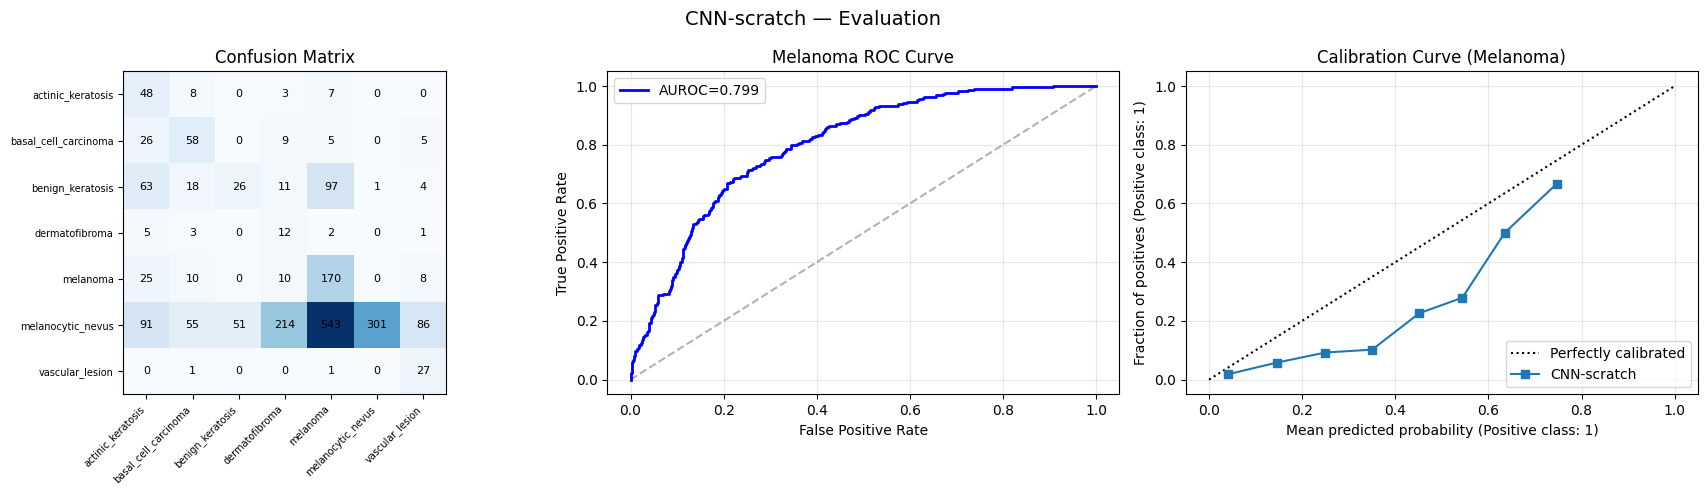


Evaluating ResNet-18 pretrained...

 ResNet-18-pt — Test Set Results
  Overall Accuracy:    42.7%
  Balanced Accuracy:   63.2%   ← imbalance-corrected
  Macro F1:            38.5%
  Melanoma Sensitivity:81.6%  (target >90%)
  Melanoma Specificity:70.7%  (target >85%)
  Melanoma AUROC:      0.845


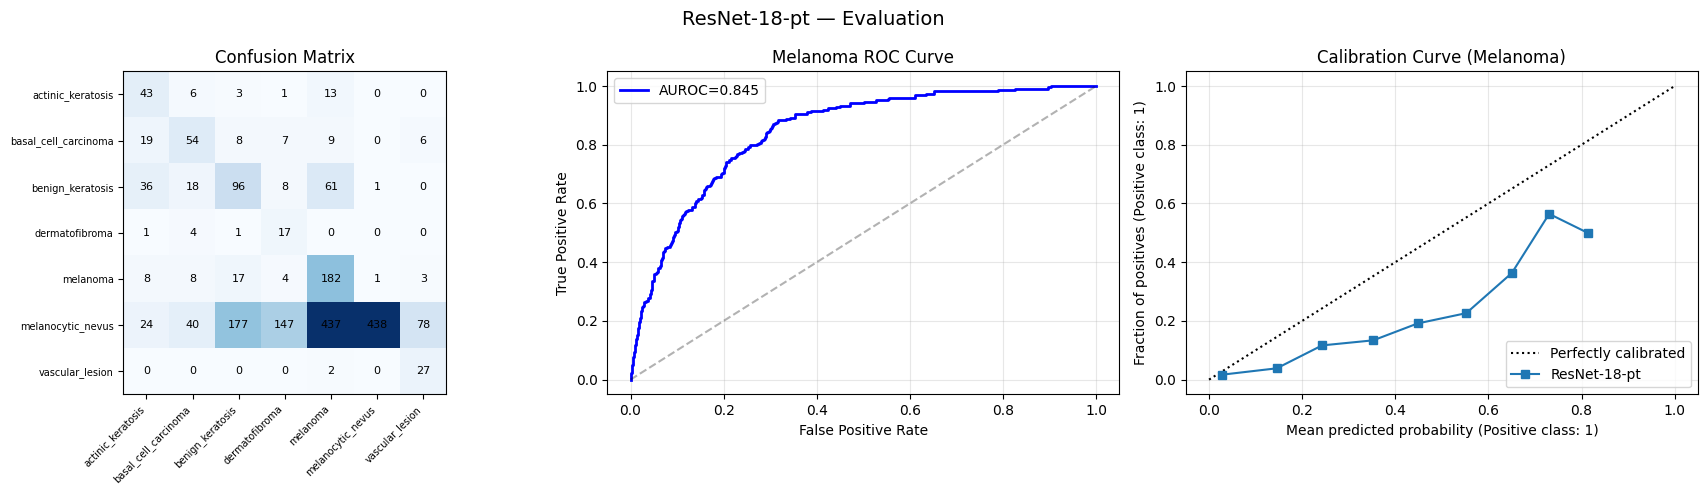


Evaluating ViT scratch...

 ViT-scratch — Test Set Results
  Overall Accuracy:    34.4%
  Balanced Accuracy:   54.1%   ← imbalance-corrected
  Macro F1:            32.3%
  Melanoma Sensitivity:77.1%  (target >90%)
  Melanoma Specificity:70.0%  (target >85%)
  Melanoma AUROC:      0.815


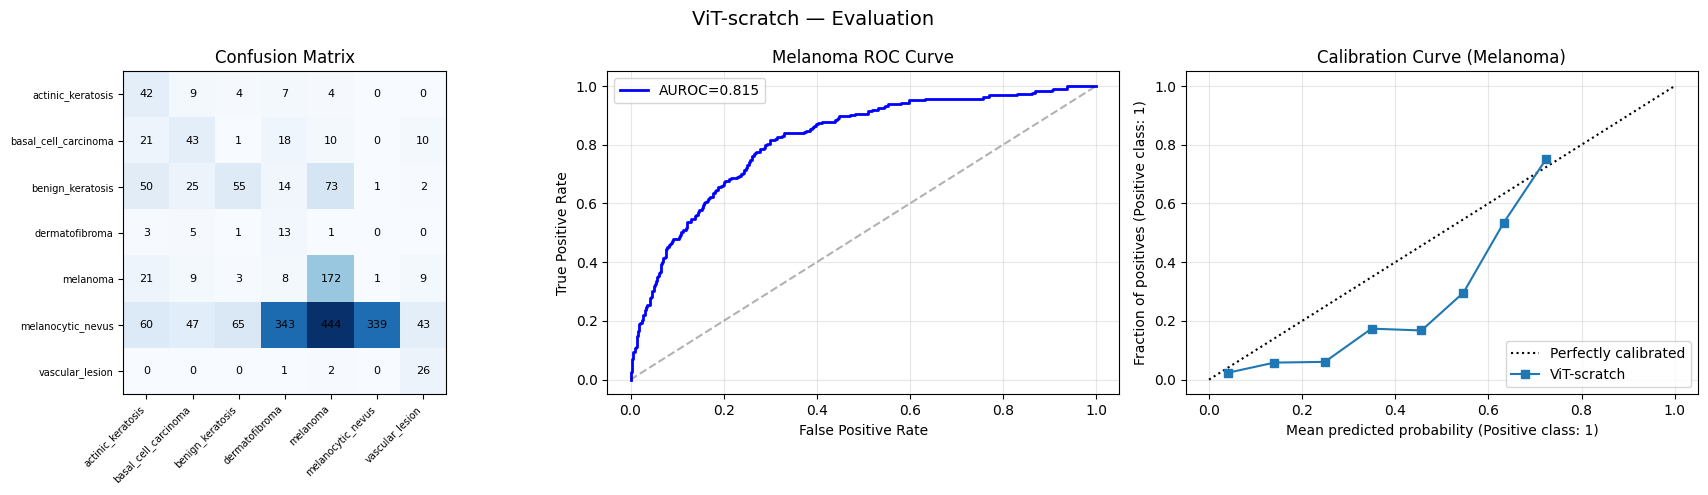


Evaluating ViT-B/16 pretrained...

 ViT-B16-pt — Test Set Results
  Overall Accuracy:    23.1%
  Balanced Accuracy:   55.6%   ← imbalance-corrected
  Macro F1:            30.8%
  Melanoma Sensitivity:87.9%  (target >90%)
  Melanoma Specificity:55.1%  (target >85%)
  Melanoma AUROC:      0.830


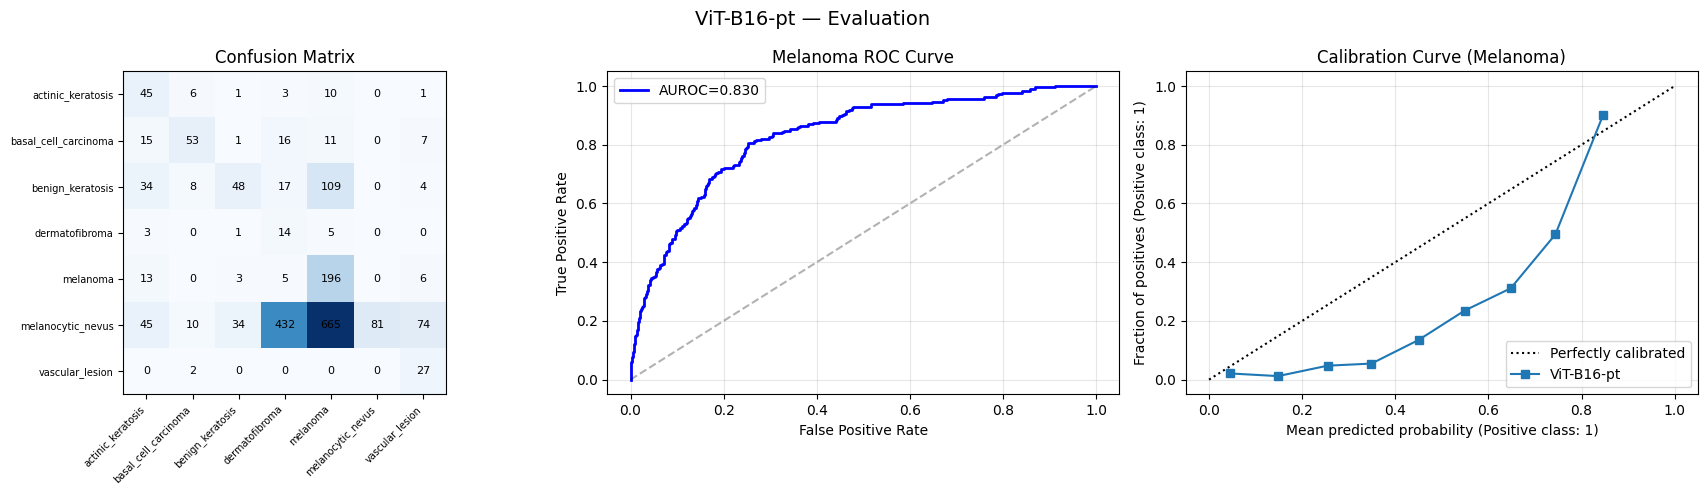

In [ ]:
# Load best checkpoints and evaluate all four models on test set
cnn_scratch.load_state_dict(cnn_best)
resnet18_pt.load_state_dict(resnet_best)
vit_scratch.load_state_dict(vit_best)
vit_b16_pt.load_state_dict(vit_b16_best)

print('Evaluating CNN scratch...')
cnn_metrics  = full_evaluation(cnn_scratch,  test_loader,     'CNN-scratch')

print('\nEvaluating ResNet-18 pretrained...')
resnet_metrics = full_evaluation(resnet18_pt, test_loader,     'ResNet-18-pt')

print('\nEvaluating ViT scratch...')
vit_metrics  = full_evaluation(vit_scratch,  test_loader,     'ViT-scratch')

print('\nEvaluating ViT-B/16 pretrained...')
vit_b16_metrics = full_evaluation(vit_b16_pt, test_loader_224, 'ViT-B16-pt')


## Section 8: Error Analysis


In [ ]:
def error_analysis(model, test_loader, model_name='Model'):
    """Identifies false negative melanoma cases for further analysis (e.g., Grad-CAM)."""
    model.eval()
    false_negatives = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            probs  = F.softmax(model(images), dim=-1)
            preds  = probs.argmax(1)

            # Identify melanoma false negatives (actual is melanoma, but predicted is not)
            mel_true_mask = (labels == MELANOMA_IDX)
            false_negative_mask = mel_true_mask & (preds != MELANOMA_IDX)

            if false_negative_mask.any():
                fn_images = images[false_negative_mask]
                fn_labels = labels[false_negative_mask]
                fn_preds  = preds[false_negative_mask]
                fn_probs  = probs[false_negative_mask]

                for i in range(fn_images.shape[0]):
                    false_negatives.append({
                        'image':     fn_images[i].cpu(),
                        'true_label': fn_labels[i].item(),
                        'predicted': fn_preds[i].item(),
                        'mel_prob':  fn_probs[i, MELANOMA_IDX].item()
                    })
    print(f"Identified {len(false_negatives)} melanoma false negatives for {model_name}.")
    return false_negatives

cnn_fn      = error_analysis(cnn_scratch,  test_loader,     'CNN-scratch')
resnet_fn   = error_analysis(resnet18_pt,  test_loader,     'ResNet-18-pt')
vit_fn      = error_analysis(vit_scratch,  test_loader,     'ViT-scratch')
vit_b16_fn  = error_analysis(vit_b16_pt,   test_loader_224, 'ViT-B16-pt')

Identified 53 melanoma false negatives for CNN-scratch.
Identified 41 melanoma false negatives for ResNet-18-pt.
Identified 51 melanoma false negatives for ViT-scratch.
Identified 27 melanoma false negatives for ViT-B16-pt.


## Section 9: Grad-CAM on False Negative Melanomas



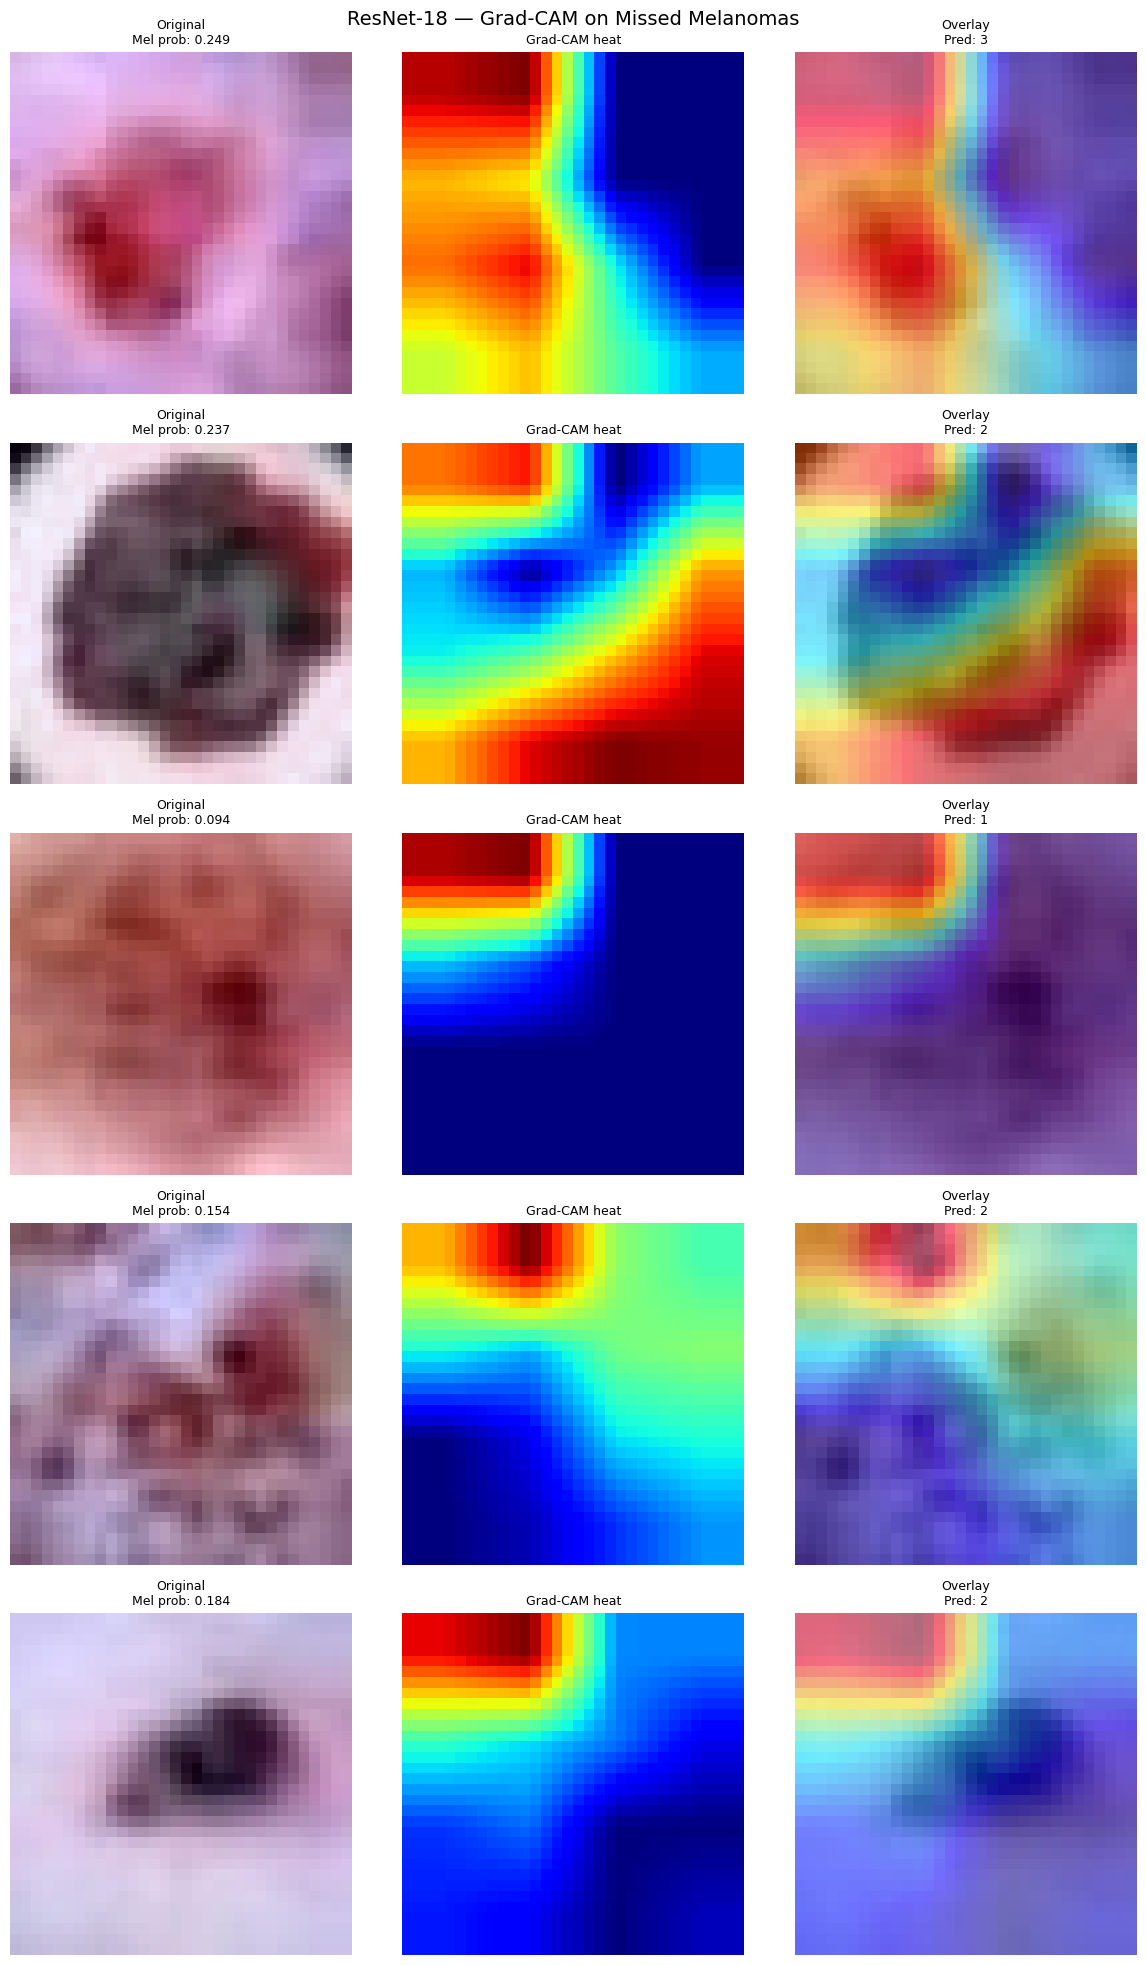

 Saved gradcam_fn_melanoma.png


In [ ]:
!pip install -q grad-cam

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


def gradcam_on_false_negatives(model, false_negatives, model_name='ResNet-18',
                                num_images=5):
    """
    FIX: Grad-CAM applied to false negative melanomas specifically,
         not random test images.
    """
    if not false_negatives:
        print(f"{model_name}: no false negatives to visualise.")
        return

    target_layers = [model.layer4[-1]]   # ResNet last conv block
    cam = GradCAM(model=model, target_layers=target_layers)

    n_show = min(num_images, len(false_negatives))
    fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show))
    if n_show == 1: axes = axes[np.newaxis, :]
    fig.suptitle(f'{model_name} — Grad-CAM on Missed Melanomas', fontsize=14)

    for i in range(n_show):
        fn        = false_negatives[i]
        img_t     = fn['image'].unsqueeze(0)          # (1,3,H,W)
        pred_cls  = MELANOMA_IDX                       # highlight melanoma region

        grayscale_cam = cam(input_tensor=img_t,
                            targets=[ClassifierOutputTarget(pred_cls)])[0]

        img_np = fn['image'].permute(1,2,0).numpy()
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
        img_np = img_np.astype(np.float32)

        cam_img = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title(f'Original\nMel prob: {fn["mel_prob"]:.3f}', fontsize=9)
        axes[i, 0].axis('off')

        axes[i, 1].imshow(grayscale_cam, cmap='jet')
        axes[i, 1].set_title('Grad-CAM heat', fontsize=9)
        axes[i, 1].axis('off')

        axes[i, 2].imshow(cam_img)
        axes[i, 2].set_title(f'Overlay\nPred: {fn["predicted"]}', fontsize=9)
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.savefig('gradcam_fn_melanoma.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(" Saved gradcam_fn_melanoma.png")


resnet18_pt.load_state_dict(resnet_best)
resnet18_pt.eval()
gradcam_on_false_negatives(resnet18_pt, resnet_fn, model_name='ResNet-18')


## Section 10: ViT Attention Rollout

Sanity check passed — 6 attention maps captured.


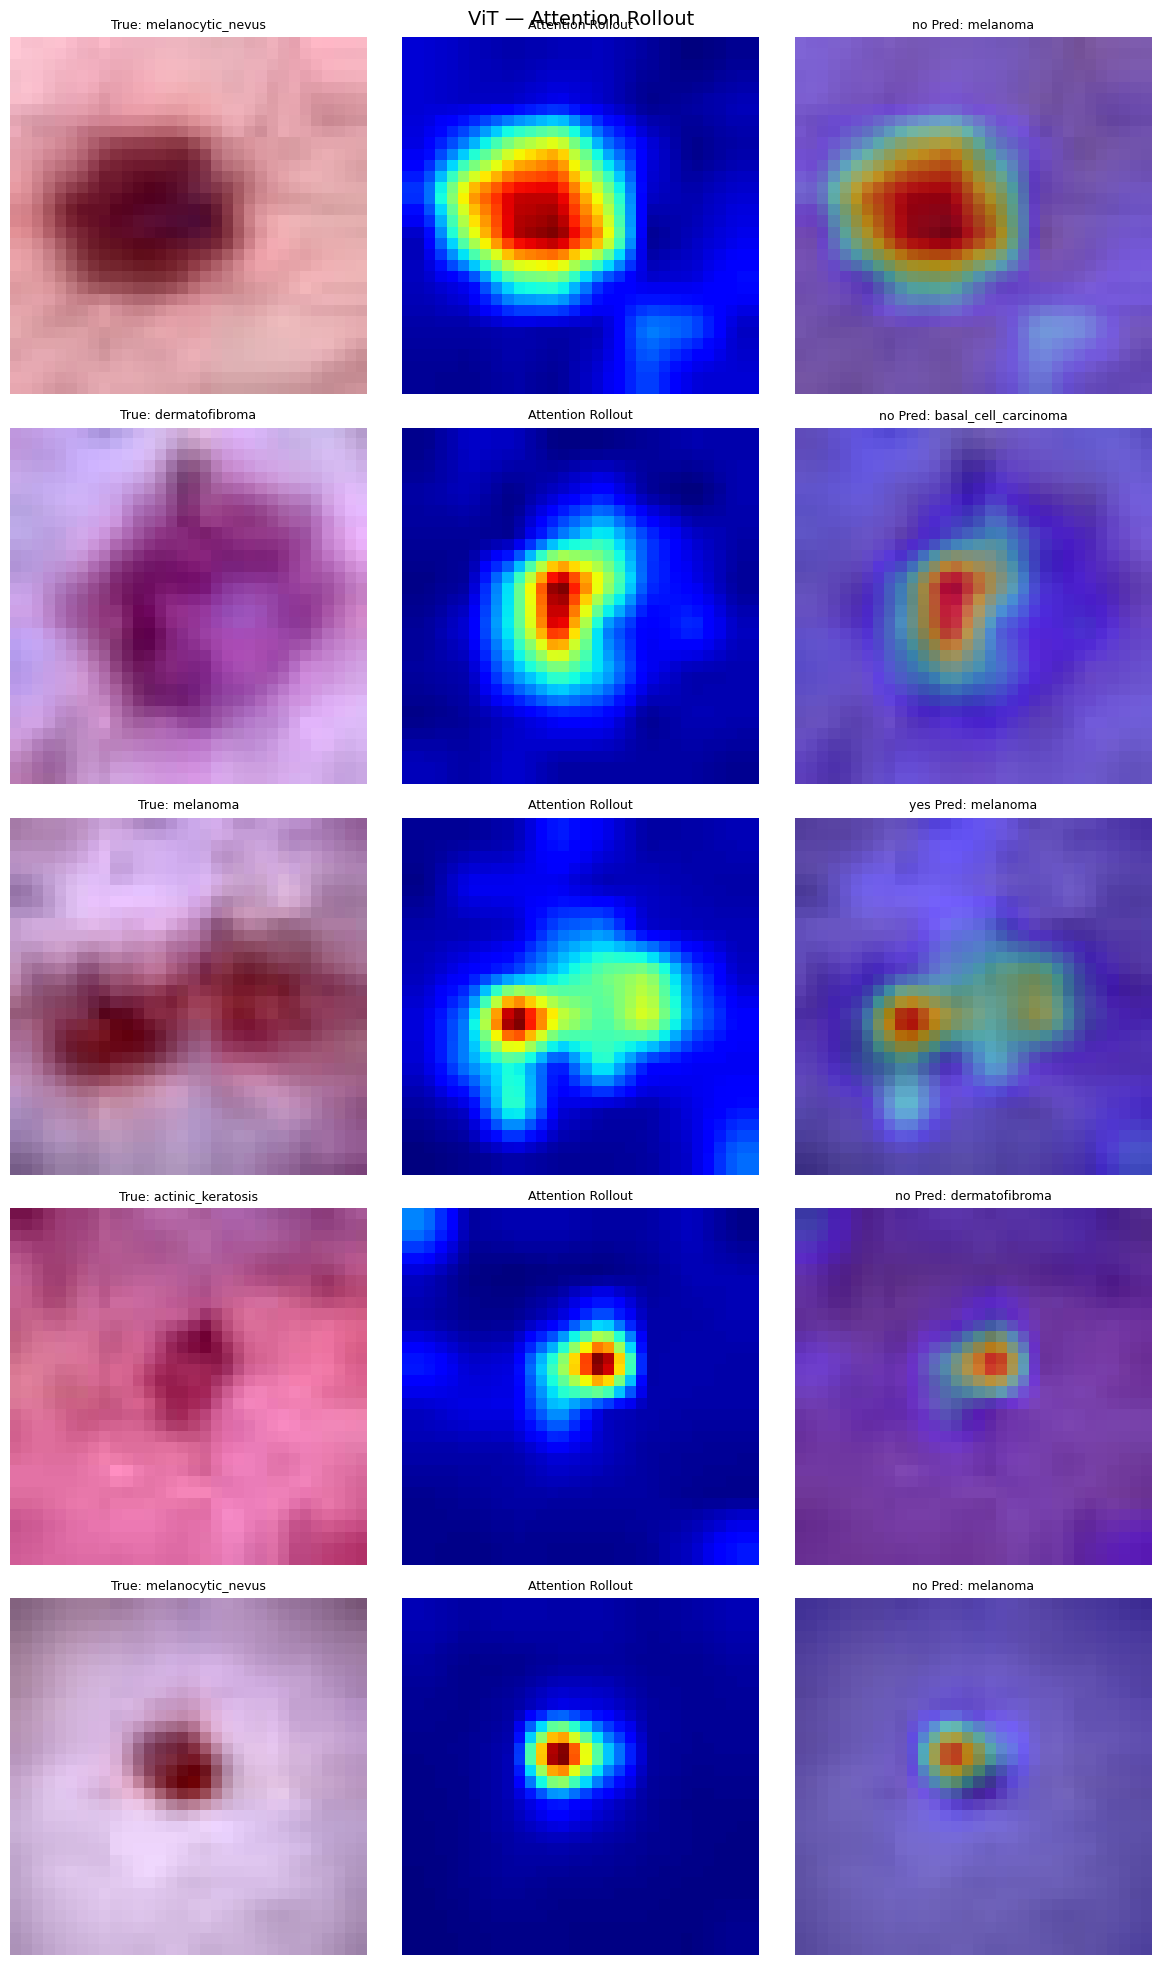

 Saved vit_attention.png


In [ ]:
import matplotlib.cm as cm
import torch.nn.functional as F_nn

torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)


def visualize_vit_attention(model, test_loader, num_images=5):
    """Visualize ViT decisions using attention rollout."""
    model.eval()
    images, labels = next(iter(test_loader))
    images = images.to(device)
    attention_maps = []

    def hook_fn(module, input, output):
        if isinstance(output, tuple) and len(output) > 1 and output[1] is not None:
            attention_maps.append(output[1].mean(dim=1).detach().cpu())

    def pre_hook_fn(module, args, kwargs):
        kwargs['need_weights']        = True
        kwargs['average_attn_weights'] = False
        return args, kwargs

    hooks = []
    for layer in model.transformer.layers:
        hooks.append(layer.self_attn.register_forward_hook(hook_fn))
        hooks.append(layer.self_attn.register_forward_pre_hook(
            pre_hook_fn, with_kwargs=True))

    dummy = torch.randn(1, 3, 32, 32).to(device)
    with torch.no_grad(): model(dummy)
    if not attention_maps:
        for h in hooks: h.remove()
        print(" No attention weights captured.")
        return
    print(f"Sanity check passed — {len(attention_maps)} attention maps captured.")
    attention_maps.clear()

    fig, axes = plt.subplots(num_images, 3, figsize=(12, 4 * num_images))
    fig.suptitle('ViT — Attention Rollout', fontsize=14)
    shown = 0

    for i in range(len(images)):
        if shown >= num_images: break
        attention_maps.clear()
        input_tensor = images[i].unsqueeze(0)
        with torch.no_grad(): pred = model(input_tensor).argmax(1).item()
        if not attention_maps: continue

        num_patches = model.num_patches
        rollout = torch.eye(num_patches + 1)
        for attn in attention_maps:
            a = attn[0]
            a = a + torch.eye(a.size(0))
            a = a / a.sum(dim=-1, keepdim=True)
            rollout = torch.mm(a, rollout)

        patch_size  = int(num_patches ** 0.5)
        mask        = rollout[0, 1:].reshape(patch_size, patch_size).numpy()
        mask        = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
        mask_res    = F_nn.interpolate(
            torch.tensor(mask).unsqueeze(0).unsqueeze(0),
            size=(32, 32), mode='bilinear', align_corners=False)[0, 0].numpy()

        img_np  = images[i].cpu().permute(1,2,0).numpy()
        img_np  = (img_np - img_np.min()) / (img_np.max() - img_np.min())
        overlay = 0.5 * img_np + 0.5 * cm.jet(mask_res)[..., :3]
        label   = labels[i].item()
        correct = "yes" if pred == label else "no"

        axes[shown, 0].imshow(img_np)
        axes[shown, 0].set_title(f'True: {CLASS_NAMES[label]}', fontsize=9)
        axes[shown, 0].axis('off')
        axes[shown, 1].imshow(mask_res, cmap='jet')
        axes[shown, 1].set_title('Attention Rollout', fontsize=9)
        axes[shown, 1].axis('off')
        axes[shown, 2].imshow(overlay)
        axes[shown, 2].set_title(f'{correct} Pred: {CLASS_NAMES[pred]}', fontsize=9)
        axes[shown, 2].axis('off')
        shown += 1

    for h in hooks: h.remove()
    plt.tight_layout()
    plt.savefig('vit_attention.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(" Saved vit_attention.png")


vit_scratch.load_state_dict(vit_best)
vit_scratch.eval()
visualize_vit_attention(vit_scratch, test_loader)

## Section 11: Deployment Optimisation — Inference Benchmarking

In [ ]:
def benchmark_inference(model, img_size=32, num_runs=100, warm_up=10):
    """Benchmarks inference time for a given model."""
    model.eval()
    dummy_input = torch.randn(1, 3, img_size, img_size).to(device)

    # Warm-up runs
    for _ in range(warm_up):
        with torch.no_grad():
            _ = model(dummy_input)

    # Benchmark runs
    start_time = time.time()
    for _ in range(num_runs):
        with torch.no_grad():
            _ = model(dummy_input)
    end_time = time.time()

    avg_time_ms = (end_time - start_time) / num_runs * 1000
    return avg_time_ms

print('CNN scratch Inference:')
cnn_latency    = benchmark_inference(cnn_scratch,  img_size=32)

print('\nResNet-18 pretrained Inference:')
resnet_latency = benchmark_inference(resnet18_pt,  img_size=32)

print('\nViT scratch Inference:')
vit_latency    = benchmark_inference(vit_scratch,  img_size=32)

print('\nViT-B/16 pretrained Inference (224×224):')
vit_b16_latency = benchmark_inference(vit_b16_pt,  img_size=224)

print(f'\nSummary:')
print(f'  CNN scratch:       {cnn_latency:.1f} ms')
print(f'  ResNet-18 pt:      {resnet_latency:.1f} ms')
print(f'  ViT scratch:       {vit_latency:.1f} ms')
print(f'  ViT-B/16 pt:       {vit_b16_latency:.1f} ms')

CNN scratch Inference:

ResNet-18 pretrained Inference:

ViT scratch Inference:

ViT-B/16 pretrained Inference (224×224):

Summary:
  CNN scratch:       1.1 ms
  ResNet-18 pt:      2.8 ms
  ViT scratch:       2.5 ms
  ViT-B/16 pt:       15.4 ms


## Section 12: Model Comparison Summary

In [ ]:
print('=' * 90)
print('DermaScan AI: 4-Model Comparison Summary')
print('=' * 90)
header = f'{"Metric":<25} {"CNN-scratch":<16} {"ResNet18-pt":<16} {"ViT-scratch":<16} {"ViT-B16-pt":<16} {"Target":<10}'
print(header)
print('-' * 90)

rows = [
    ('Overall Accuracy',
     f'{cnn_metrics["accuracy"]:.1f}%',
     f'{resnet_metrics["accuracy"]:.1f}%',
     f'{vit_metrics["accuracy"]:.1f}%',
     f'{vit_b16_metrics["accuracy"]:.1f}%',
     '>84%'),
    ('Balanced Accuracy',
     f'{cnn_metrics["balanced_acc"]:.1f}%',
     f'{resnet_metrics["balanced_acc"]:.1f}%',
     f'{vit_metrics["balanced_acc"]:.1f}%',
     f'{vit_b16_metrics["balanced_acc"]:.1f}%',
     '—'),
    ('Macro F1',
     f'{cnn_metrics["macro_f1"]:.1f}%',
     f'{resnet_metrics["macro_f1"]:.1f}%',
     f'{vit_metrics["macro_f1"]:.1f}%',
     f'{vit_b16_metrics["macro_f1"]:.1f}%',
     '—'),
    ('Mel. Sensitivity',
     f'{cnn_metrics["mel_sensitivity"]:.1f}%',
     f'{resnet_metrics["mel_sensitivity"]:.1f}%',
     f'{vit_metrics["mel_sensitivity"]:.1f}%',
     f'{vit_b16_metrics["mel_sensitivity"]:.1f}%',
     '>90%'),
    ('Mel. Specificity',
     f'{cnn_metrics["mel_specificity"]:.1f}%',
     f'{resnet_metrics["mel_specificity"]:.1f}%',
     f'{vit_metrics["mel_specificity"]:.1f}%',
     f'{vit_b16_metrics["mel_specificity"]:.1f}%',
     '>85%'),
    ('Mel. AUROC',
     f'{cnn_metrics["mel_auroc"]:.3f}',
     f'{resnet_metrics["mel_auroc"]:.3f}',
     f'{vit_metrics["mel_auroc"]:.3f}',
     f'{vit_b16_metrics["mel_auroc"]:.3f}',
     '>0.92'),
    ('Inference (ms)',
     f'{cnn_latency:.1f}',
     f'{resnet_latency:.1f}',
     f'{vit_latency:.1f}',
     f'{vit_b16_latency:.1f}',
     '<3000'),
]
for label, c_val, r_val, v_val, vb_val, t in rows:
    print(f'{label:<25} {c_val:<16} {r_val:<16} {v_val:<16} {vb_val:<16} {t:<10}')

print('\n Research Finding:')
print('   Compare ResNet18-pt vs CNN-scratch → impact of pretraining on CNN')
print('   Compare ViT-B16-pt vs ViT-scratch  → impact of pretraining on Transformers')
print('   Compare ViT-B16-pt vs ResNet18-pt  → architecture effect (both pretrained)')
print('   Compare ViT-scratch vs CNN-scratch → architecture effect (both from scratch)')



DermaScan AI: 4-Model Comparison Summary
Metric                    CNN-scratch      ResNet18-pt      ViT-scratch      ViT-B16-pt       Target    
------------------------------------------------------------------------------------------
Overall Accuracy          32.0%            42.7%            34.4%            23.1%            >84%      
Balanced Accuracy         55.0%            63.2%            54.1%            55.6%            —         
Macro F1                  29.1%            38.5%            32.3%            30.8%            —         
Mel. Sensitivity          76.2%            81.6%            77.1%            87.9%            >90%      
Mel. Specificity          63.2%            70.7%            70.0%            55.1%            >85%      
Mel. AUROC                0.799            0.845            0.815            0.830            >0.92     
Inference (ms)            1.1              2.8              2.5              15.4             <3000     

 Research Finding:
   Compa

## Section 13: Save Models

In [ ]:
models_to_save = [
    ('dermascan_cnn_scratch.pth',   cnn_scratch,  cnn_best,     'cnn_scratch',    32),
    ('dermascan_resnet18_pt.pth',   resnet18_pt,  resnet_best,  'resnet18_pt',    32),
    ('dermascan_vit_scratch.pth',   vit_scratch,  vit_best,     'vit_scratch',    32),
    ('dermascan_vit_b16_pt.pth',    vit_b16_pt,   vit_b16_best, 'vit_b16_pt',    224),
]

for filename, model, best_state, model_name, img_size in models_to_save:
    torch.save({
        'model_name':       model_name,
        'model_state_dict': best_state,
        'class_names':      CLASS_NAMES,
        'num_classes':      NUM_CLASSES,
        'img_size':         img_size,
    }, filename)
    size_mb = os.path.getsize(filename) / 1e6
    print(f' Saved {filename} ({size_mb:.1f} MB)')


 Saved dermascan_cnn_scratch.pth (2.5 MB)
 Saved dermascan_resnet18_pt.pth (44.8 MB)
 Saved dermascan_vit_scratch.pth (10.9 MB)
 Saved dermascan_vit_b16_pt.pth (343.3 MB)


## Section 14: Save Metrics JSON

In [ ]:
summary = {
    'cnn_scratch': {
        'accuracy':        round(cnn_metrics['accuracy'], 2),
        'balanced_acc':    round(cnn_metrics['balanced_acc'], 2),
        'macro_f1':        round(cnn_metrics['macro_f1'], 2),
        'mel_sensitivity': round(cnn_metrics['mel_sensitivity'], 2),
        'mel_specificity': round(cnn_metrics['mel_specificity'], 2),
        'mel_auroc':       round(cnn_metrics['mel_auroc'], 4),
        'inference_ms':    round(cnn_latency, 2),
        'params': sum(p.numel() for p in cnn_scratch.parameters()),
    },
    'resnet18_pt': {
        'accuracy':        round(resnet_metrics['accuracy'], 2),
        'balanced_acc':    round(resnet_metrics['balanced_acc'], 2),
        'macro_f1':        round(resnet_metrics['macro_f1'], 2),
        'mel_sensitivity': round(resnet_metrics['mel_sensitivity'], 2),
        'mel_specificity': round(resnet_metrics['mel_specificity'], 2),
        'mel_auroc':       round(resnet_metrics['mel_auroc'], 4),
        'inference_ms':    round(resnet_latency, 2),
        'params': sum(p.numel() for p in resnet18_pt.parameters()),
    },
    'vit_scratch': {
        'accuracy':        round(vit_metrics['accuracy'], 2),
        'balanced_acc':    round(vit_metrics['balanced_acc'], 2),
        'macro_f1':        round(vit_metrics['macro_f1'], 2),
        'mel_sensitivity': round(vit_metrics['mel_sensitivity'], 2),
        'mel_specificity': round(vit_metrics['mel_specificity'], 2),
        'mel_auroc':       round(vit_metrics['mel_auroc'], 4),
        'inference_ms':    round(vit_latency, 2),
        'params': sum(p.numel() for p in vit_scratch.parameters()),
    },
    'vit_b16_pt': {
        'accuracy':        round(vit_b16_metrics['accuracy'], 2),
        'balanced_acc':    round(vit_b16_metrics['balanced_acc'], 2),
        'macro_f1':        round(vit_b16_metrics['macro_f1'], 2),
        'mel_sensitivity': round(vit_b16_metrics['mel_sensitivity'], 2),
        'mel_specificity': round(vit_b16_metrics['mel_specificity'], 2),
        'mel_auroc':       round(vit_b16_metrics['mel_auroc'], 4),
        'inference_ms':    round(vit_b16_latency, 2),
        'params': sum(p.numel() for p in vit_b16_pt.parameters()),
    },
    'class_names':  CLASS_NAMES,
    'melanoma_idx': MELANOMA_IDX,
    'dataset':      'DermaMNIST (HAM10000)',
    'research_question': 'How much does pretraining matter vs architecture for medical imaging?',
}

with open('model_metrics.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(' Metrics saved to model_metrics.json')
print(json.dumps(summary, indent=2))


 Metrics saved to model_metrics.json
{
  "cnn_scratch": {
    "accuracy": 32.02,
    "balanced_acc": 54.97,
    "macro_f1": 29.11,
    "mel_sensitivity": 76.23,
    "mel_specificity": 63.24,
    "mel_auroc": 0.799,
    "inference_ms": 1.11,
    "params": 617383
  },
  "resnet18_pt": {
    "accuracy": 42.74,
    "balanced_acc": 63.22,
    "macro_f1": 38.49,
    "mel_sensitivity": 81.61,
    "mel_specificity": 70.71,
    "mel_auroc": 0.845,
    "inference_ms": 2.82,
    "params": 11172423
  },
  "vit_scratch": {
    "accuracy": 34.41,
    "balanced_acc": 54.14,
    "macro_f1": 32.32,
    "mel_sensitivity": 77.13,
    "mel_specificity": 70.03,
    "mel_auroc": 0.8154,
    "inference_ms": 2.49,
    "params": 2730055
  },
  "vit_b16_pt": {
    "accuracy": 23.14,
    "balanced_acc": 55.62,
    "macro_f1": 30.81,
    "mel_sensitivity": 87.89,
    "mel_specificity": 55.11,
    "mel_auroc": 0.83,
    "inference_ms": 15.39,
    "params": 85804039
  },
  "class_names": [
    "actinic_keratosis",


## Section 15: HuggingFace Hub Upload

**Security fix:** token is read from Colab Secrets — never hardcoded in the notebook.

> **Setup:** In Colab, click the 🔑 key icon → add a secret named `hf_token` with your HuggingFace token.

In [ ]:
!pip install -q huggingface_hub

from google.colab import userdata
from huggingface_hub import HfApi, login

hf_token = userdata.get('hf_token')
login(token=hf_token)

api     = HfApi()
REPO_ID = "mahveen123/dermascan-ai"

api.create_repo(repo_id=REPO_ID, exist_ok=True)

upload_files = [
    'dermascan_cnn_scratch.pth',
    'dermascan_resnet18_pt.pth',
    'dermascan_vit_scratch.pth',
    'dermascan_vit_b16_pt.pth',
    'model_metrics.json',
    'gradcam_fn_melanoma.png',
    'training_curves_4models.png',
]

for filename in upload_files:
    if os.path.exists(filename):
        api.upload_file(path_or_fileobj=filename,
                        path_in_repo=filename, repo_id=REPO_ID)
        print(f'Uploaded {filename}')
    else:
        print(f' {filename} not found — skipping')

print(f'\nModel repo: https://huggingface.co/{REPO_ID}')


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  dermascan_cnn_scratch.pth   :  23%|##2       |  561kB / 2.49MB            

Uploaded dermascan_cnn_scratch.pth


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

...

Uploaded gradcam_fn_melanoma.png


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  training_curves_4models.png : 100%|##########|  409kB /  409kB            

Uploaded training_curves_4models.png

Model repo: https://huggingface.co/mahveen123/dermascan-ai


## Section 16: Verify Round-Trip Load from HuggingFace

In [ ]:
from huggingface_hub import hf_hub_download

# Verify the best model (ViT-B/16 pretrained) loads correctly
path       = hf_hub_download(repo_id=REPO_ID, filename='dermascan_vit_b16_pt.pth')
checkpoint = torch.load(path, map_location='cpu', weights_only=False)

test_model = create_vit_b16_pretrained().to('cpu')
test_model.load_state_dict(checkpoint['model_state_dict'])
test_model.eval()

img_size = checkpoint['img_size']
dummy    = torch.randn(1, 3, img_size, img_size)
with torch.no_grad():
    out = test_model(dummy)

print('ViT-B/16 pretrained loaded from HF Hub successfully')
print(f'   Output shape: {out.shape}')
print(f'   Classes:      {checkpoint["class_names"]}')
print(f'   Input size:   {img_size}×{img_size}')

# Also verify ResNet-18 (used in Gradio app)
path2       = hf_hub_download(repo_id=REPO_ID, filename='dermascan_resnet18_pt.pth')
checkpoint2 = torch.load(path2, map_location='cpu', weights_only=False)
test_model2 = create_resnet18_pretrained().to('cpu')
test_model2.load_state_dict(checkpoint2['model_state_dict'])
test_model2.eval()
with torch.no_grad():
    out2 = test_model2(torch.randn(1, 3, 32, 32))
print('R esNet-18 pretrained loaded from HF Hub successfully')


dermascan_vit_b16_pt.pth:   0%|          | 0.00/343M [00:00<?, ?B/s]

ViT-B/16 pretrained loaded from HF Hub successfully
   Output shape: torch.Size([1, 7])
   Classes:      ['actinic_keratosis', 'basal_cell_carcinoma', 'benign_keratosis', 'dermatofibroma', 'melanoma', 'melanocytic_nevus', 'vascular_lesion']
   Input size:   224×224


dermascan_resnet18_pt.pth:   0%|          | 0.00/44.8M [00:00<?, ?B/s]

R esNet-18 pretrained loaded from HF Hub successfully






## Section 17: Deploy Gradio App to HuggingFace Spaces

In [ ]:
import os
files_to_check = [
    "dermascan_cnn_scratch.pth",
    "dermascan_resnet18_pt.pth",
    "dermascan_vit_scratch.pth",
    "dermascan_vit_b16_pt.pth",
    "model_metrics.json"
]
for f in files_to_check:
    exists = os.path.exists(f)
    size   = os.path.getsize(f)/1e6 if exists else 0
    print(f"{'' if exists else ''} {f:<35} {size:.1f} MB")

 dermascan_cnn_scratch.pth           2.5 MB
 dermascan_resnet18_pt.pth           44.8 MB
 dermascan_vit_scratch.pth           10.9 MB
 dermascan_vit_b16_pt.pth            343.3 MB
 model_metrics.json                  0.0 MB


In [ ]:
import torch

for fname in ["dermascan_cnn_scratch.pth", "dermascan_resnet18_pt.pth",
              "dermascan_vit_scratch.pth", "dermascan_vit_b16_pt.pth"]:
    ck = torch.load(fname, map_location="cpu", weights_only=False)
    print(f"\n{'='*50}")
    print(f"FILE: {fname}")
    print(f"Keys: {[k for k in ck.keys() if k != 'model_state_dict']}")
    print("Architecture:")
    for k, v in ck["model_state_dict"].items():
        print(f"  {k:<50} {str(v.shape)}")


FILE: dermascan_cnn_scratch.pth
Keys: ['model_name', 'class_names', 'num_classes', 'img_size']
Architecture:
  features.0.weight                                  torch.Size([32, 3, 3, 3])
  features.0.bias                                    torch.Size([32])
  features.1.weight                                  torch.Size([32])
  features.1.bias                                    torch.Size([32])
  features.1.running_mean                            torch.Size([32])
  features.1.running_var                             torch.Size([32])
  features.1.num_batches_tracked                     torch.Size([])
  features.3.weight                                  torch.Size([32, 32, 3, 3])
  features.3.bias                                    torch.Size([32])
  features.4.weight                                  torch.Size([32])
  features.4.bias                                    torch.Size([32])
  features.4.running_mean                            torch.Size([32])
  features.4.running_var         

In [ ]:
%%writefile app.py
import gradio as gr
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from huggingface_hub import hf_hub_download
import json

REPO_ID     = "mahveen123/dermascan-ai"
NUM_CLASSES = 7
CLASS_NAMES = ['actinic_keratosis','basal_cell_carcinoma','benign_keratosis',
               'dermatofibroma','melanoma','melanocytic_nevus','vascular_lesion']
MELANOMA_IDX = 4

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

transform_32 = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
transform_224 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class CNNFromScratch(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),   # 0
            nn.BatchNorm2d(32),                # 1
            nn.ReLU(),                         # 2
            nn.Conv2d(32, 32, 3, padding=1),  # 3
            nn.BatchNorm2d(32),                # 4
            nn.ReLU(),                         # 5
            nn.MaxPool2d(2),                   # 6
            nn.Conv2d(32, 64, 3, padding=1),  # 7
            nn.BatchNorm2d(64),                # 8
            nn.ReLU(),                         # 9
            nn.Conv2d(64, 64, 3, padding=1),  # 10
            nn.BatchNorm2d(64),                # 11
            nn.ReLU(),                         # 12
            nn.MaxPool2d(2),                   # 13
            nn.Conv2d(64, 128, 3, padding=1), # 14
            nn.BatchNorm2d(128),               # 15
            nn.ReLU(),                         # 16
            nn.Conv2d(128, 128, 3, padding=1),# 17
            nn.BatchNorm2d(128),               # 18
            nn.ReLU(),                         # 19
            nn.MaxPool2d(2),                   # 20
            nn.Conv2d(128, 256, 3, padding=1),# 21
            nn.BatchNorm2d(256),               # 22
            nn.AdaptiveAvgPool2d(1),           # 23
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 7),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

def create_resnet18():
    m = models.resnet18(weights=None)
    m.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    m.fc      = nn.Linear(512, NUM_CLASSES)
    return m

class ViTFromScratch(nn.Module):
    def __init__(self, img_size=32, patch_size=4, embed_dim=192,
                 num_heads=3, num_layers=6, num_classes=7, dropout=0.1):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.patch_embed  = nn.Conv2d(3, embed_dim, patch_size, stride=patch_size)
        self.cls_token    = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed    = nn.Parameter(torch.randn(1, self.num_patches + 1, embed_dim) * 0.02)
        self.pos_drop     = nn.Dropout(dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            activation='gelu', batch_first=True,
            norm_first=True, dropout=dropout)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, num_classes),
        )
    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x).flatten(2).transpose(1, 2)
        x = torch.cat([self.cls_token.expand(B, -1, -1), x], dim=1) + self.pos_embed
        x = self.pos_drop(x)
        x = self.norm(self.transformer(x))
        return self.head(x[:, 0])

def create_vit_b16():
    import timm
    return timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=NUM_CLASSES)

MODEL_CFG = {
    "CNN Scratch":          ("dermascan_cnn_scratch.pth",  CNNFromScratch,  transform_32),
    "ResNet-18 Pretrained": ("dermascan_resnet18_pt.pth",  create_resnet18, transform_32),
    "ViT Scratch":          ("dermascan_vit_scratch.pth",  ViTFromScratch,  transform_32),
    "ViT-B16 Pretrained":   ("dermascan_vit_b16_pt.pth",   create_vit_b16,  transform_224),
}

def load_model(filename, create_fn):
    path = hf_hub_download(repo_id=REPO_ID, filename=filename)
    ck   = torch.load(path, map_location="cpu", weights_only=False)
    m    = create_fn()
    m.load_state_dict(ck["model_state_dict"])
    m.eval()
    return m

print("Loading models...")
LOADED = {}
for name, (fname, fn, _) in MODEL_CFG.items():
    try:
        LOADED[name] = load_model(fname, fn)
        print(f"✅ {name}")
    except Exception as e:
        print(f"❌ {name}: {e}")
        LOADED[name] = None

CLASS_INFO = {
    "actinic_keratosis":    "Pre-cancerous UV lesion. Monitor and consult a dermatologist.",
    "basal_cell_carcinoma": "Common skin cancer. Treatable if caught early.",
    "benign_keratosis":     "Non-cancerous growth. No treatment usually needed.",
    "dermatofibroma":       "Benign fibrous nodule. Harmless in most cases.",
    "melanoma":             "Malignant skin cancer. Consult a dermatologist immediately.",
    "melanocytic_nevus":    "Common mole. Monitor for changes (ABCDE rule).",
    "vascular_lesion":      "Blood vessel abnormality. Usually benign.",
}

def predict(image, model_name):
    if image is None:
        return "", "", gr.update(value=None, visible=False)
    model = LOADED.get(model_name)
    if model is None:
        return "<p style='color:red'>Model failed to load.</p>", "", gr.update(visible=False)
    _, _, tfm = MODEL_CFG[model_name]
    img = tfm(image).unsqueeze(0)
    with torch.no_grad():
        probs = F.softmax(model(img), dim=1)[0]
    pred_idx   = probs.argmax().item()
    pred_name  = CLASS_NAMES[pred_idx]
    mel_prob   = probs[MELANOMA_IDX].item()
    confidence = float(probs[pred_idx]) * 100
    if mel_prob > 0.4:
        risk_html = f'<div style="background:#2d0f0f;border:2px solid #dc2626;border-radius:10px;padding:16px 20px;color:#fca5a5;font-weight:600;">🔴 HIGH RISK — Melanoma probability: {mel_prob*100:.1f}%<br><span style="font-weight:400;font-size:0.85rem;">Consult a dermatologist immediately.</span></div>'
    elif mel_prob > 0.2:
        risk_html = f'<div style="background:#2d2200;border:2px solid #d97706;border-radius:10px;padding:16px 20px;color:#fcd34d;font-weight:600;">🟡 MEDIUM RISK — Melanoma probability: {mel_prob*100:.1f}%<br><span style="font-weight:400;font-size:0.85rem;">Monitor closely and consider professional evaluation.</span></div>'
    else:
        risk_html = f'<div style="background:#0f2d1a;border:2px solid #16a34a;border-radius:10px;padding:16px 20px;color:#86efac;font-weight:600;">🟢 LOW RISK — Melanoma probability: {mel_prob*100:.1f}%<br><span style="font-weight:400;font-size:0.85rem;">Appears benign. Continue regular skin checks.</span></div>'
    desc = CLASS_INFO.get(pred_name, "See a dermatologist for advice.")
    pred_html = f'<div style="background:#1a1f2e;border:1px solid #2a3a5c;border-radius:12px;padding:20px;margin-bottom:12px;"><div style="font-size:1.3rem;font-weight:700;color:#e2e8f0;margin-bottom:6px;">{pred_name.replace("_"," ")}</div><div style="color:#94a3b8;font-size:0.9rem;margin-bottom:8px;">Confidence: <strong>{confidence:.1f}%</strong></div><div style="color:#64748b;font-size:0.85rem;border-top:1px solid #2a3a5c;padding-top:10px;">{desc}</div></div>'
    scores = {CLASS_NAMES[i].replace("_", " "): float(probs[i]) for i in range(NUM_CLASSES)}
    return pred_html, risk_html, gr.update(value=scores, visible=True)

with gr.Blocks(title="DermaScan AI") as demo:
    gr.HTML("""<div style="display:flex;align-items:center;gap:16px;background:#1a1f2e;border:1px solid #2a3a5c;border-radius:16px;padding:24px 32px;margin-bottom:16px;"><div style="font-size:48px;">🔬</div><div><h1 style="margin:0;font-size:2rem;font-weight:700;background:linear-gradient(90deg,#4f8ef7,#a78bfa);-webkit-background-clip:text;-webkit-text-fill-color:transparent;">DermaScan AI</h1><p style="color:#8892a4;margin:4px 0 0;">Melanoma &amp; Skin Lesion Classifier · CNN · ResNet-18 · ViT-Scratch · ViT-B16</p></div></div>""")
    gr.HTML("""<div style="background:#1e1a0e;border-left:4px solid #f59e0b;border-radius:8px;padding:12px 16px;color:#fbbf24;font-size:0.88rem;margin-bottom:16px;">⚠️ <strong>Medical Disclaimer:</strong> For educational and research purposes only. Not a substitute for professional medical advice.</div>""")
    with gr.Row():
        with gr.Column(scale=1):
            gr.HTML('<p style="font-weight:600;color:#a78bfa;">📤 Upload dermoscopy image</p>')
            img_input = gr.Image(type="pil", label="Skin lesion image", height=300)
            model_selector = gr.Dropdown(choices=list(MODEL_CFG.keys()), value="ResNet-18 Pretrained", label="🤖 Select Model")
            submit_btn = gr.Button("🔍 Analyse Lesion", variant="primary", size="lg")
            gr.HTML("""<div style="background:#111827;border:1px solid #2a3a5c;border-radius:10px;padding:14px 16px;font-size:0.85rem;color:#9ca3af;margin-top:12px;"><strong>💡 Tips:</strong><ul style="margin:6px 0 0 16px;"><li>Use clear dermoscopy or close-up photos</li><li>Centre the lesion in frame</li><li>Ensure good lighting</li></ul></div>""")
        with gr.Column(scale=1):
            gr.HTML('<p style="font-weight:600;color:#a78bfa;">📊 Results</p>')
            out_pred  = gr.HTML()
            out_risk  = gr.HTML()
            out_chart = gr.Label(label="Class Probabilities", num_top_classes=7, visible=False)
    submit_btn.click(fn=predict, inputs=[img_input, model_selector],
                     outputs=[out_pred, out_risk, out_chart])
    gr.HTML("""<div style="text-align:center;color:#4b5563;font-size:0.82rem;padding:20px;border-top:1px solid #1f2937;margin-top:16px;">CNN · ResNet-18 · ViT-Scratch · ViT-B16 · PyTorch + Gradio + timm</div>""")

demo.launch()

Writing app.py


In [ ]:
with open("requirements.txt", "w") as f:
    f.write("torch\ntorchvision\ngradio\nhuggingface_hub\nPillow\nnumpy\ntimm\n")

from huggingface_hub import HfApi
from google.colab import userdata
token = userdata.get('hf_token')
api = HfApi()

api.upload_file(path_or_fileobj="app.py", path_in_repo="app.py",
                repo_id="mahveen123/dermascan", repo_type="space",
                commit_message="Fresh app", token=token)
print(" app.py uploaded")

api.upload_file(path_or_fileobj="requirements.txt", path_in_repo="requirements.txt",
                repo_id="mahveen123/dermascan", repo_type="space",
                commit_message="requirements", token=token)
print(" requirements.txt uploaded")

api.restart_space(repo_id="mahveen123/dermascan", token=token)
print(" Done — wait 90 seconds then open:")
print("https://huggingface.co/spaces/mahveen123/dermascan")

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


 app.py uploaded
 requirements.txt uploaded
 Done — wait 90 seconds then open:
https://huggingface.co/spaces/mahveen123/dermascan
